\definecolor{uomaccent}{HTML}{55499C}

\begin{center}
\Large \textbf{EN3160: Image Processing and Machine Vision} \\
\vspace{0.2cm}
{\Large \textbf{\color{uomaccent} Assignment 1: Intensity Transformations and Neighborhood Filtering}} \\
\vspace{0.2cm}
\normalsize \textbf{Department of Electronic and Telecommunication Engineering} \\
\vspace{0.2cm}
\normalsize \textbf{University of Moratuwa}\\
\vspace{0.2cm}
\normalsize \textbf{September 14, 2026}
\end{center}

\vspace{0.4cm}

\noindent\textbf{Name:} Samarasinghe S.M.R.R. \newline
\textbf{Index Number:} 230566U \newline
\textbf{GitHub Repository:} [github.com/RumethRanhinda/EN3160-Vision-UoM](https://github.com/RumethRanhinda/EN3160-Vision-UoM/tree/main/Assignments/Intensity%20Transformations%20and%20Spatial%20Filtering)

\noindent\rule{\textwidth}{0.5pt}

\vspace{0.4cm}

\noindent\textbf{\color{uomaccent} 1. Intensity Transformation}

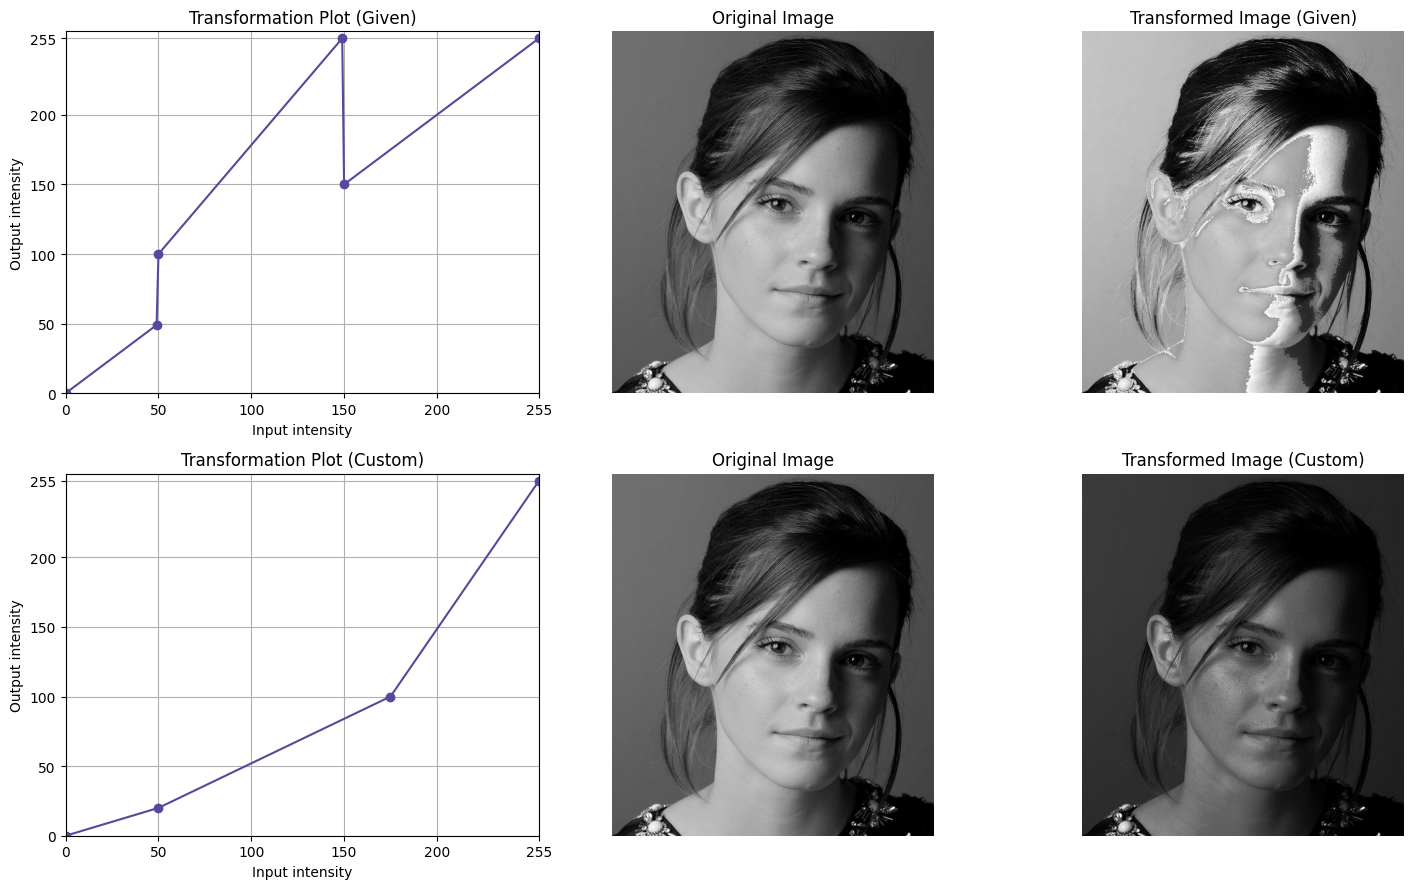

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    bp = np.array(breakpoints)
    xp = bp[:, 0]  # Input intensities
    yp = bp[:, 1]  # Output intensities

    transformed_im = np.interp(im.flatten(), xp, yp).reshape(im.shape) # Apply interpolation
    
    return transformed_im.astype(np.uint8)

img = cv2.imread('Images/emma.jpeg', cv2.IMREAD_GRAYSCALE)
bp_given = [[0, 0], [49, 49], [50, 100], [149, 255], [150, 150], [255, 255]] # Provided breakpoints 
bp_custom = [[0, 0], [50, 20], [175, 100], [255, 255]] # Custom breakpoints

transformed_given = intensity_transform(img, bp_given)
transformed_custom = intensity_transform(img, bp_custom)

grid_ticks = [0, 50, 100, 150, 200, 255] # Grid ticks for the plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
# Given Breakpoints
bp_given_arr = np.array(bp_given)
axes[0, 0].plot(bp_given_arr[:,0], bp_given_arr[:,1], marker='o', color='#55499C')
axes[0, 0].set_title("Transformation Plot (Given)")
axes[0, 0].set_xlabel("Input intensity"); axes[0, 0].set_ylabel("Output intensity")
axes[0, 0].set_xlim([0, 255]); axes[0, 0].set_ylim([0, 260])
# Apply custom grid
axes[0, 0].set_xticks(grid_ticks); axes[0, 0].set_yticks(grid_ticks); axes[0, 0].grid(True)
axes[0, 1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Original Image"); axes[0, 1].axis('off')
axes[0, 2].imshow(transformed_given, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title("Transformed Image (Given)"); axes[0, 2].axis('off')

# Custom Breakpoints
bp_custom_arr = np.array(bp_custom)
axes[1, 0].plot(bp_custom_arr[:,0], bp_custom_arr[:,1], marker='o', color='#55499C')
axes[1, 0].set_title("Transformation Plot (Custom)")
axes[1, 0].set_xlabel("Input intensity"); axes[1, 0].set_ylabel("Output intensity")
axes[1, 0].set_xlim([0, 255]); axes[1, 0].set_ylim([0, 260])
axes[1, 0].set_xticks(grid_ticks); axes[1, 0].set_yticks(grid_ticks); axes[1, 0].grid(True)
axes[1, 1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title("Original Image"); axes[1, 1].axis('off')
axes[1, 2].imshow(transformed_custom, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title("Transformed Image (Custom)"); axes[1, 2].axis('off')
plt.tight_layout(); plt.show()

\vspace{-1cm}

The given intensity transformation made high intensities above $150$ darker in a discontinous way which explains the artifact seen in the output image.

The custom transformation was implemented with the intenstion of highlighting the freckles within the bright area of the face by providing a wider range for brigther pixels.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 2. Accentuate White and Gray Matter}

The idea is to first find the threshold value of intensity which determines white and dark matter, and in each case providing a wider range via intensity transformation, for input pixel values within that threshold range.

\begin{itemize}
    \item \textbf{For White Matter:} 140 - 185 
    \item \textbf{For Dark Matter:} 175 - 255
\end{itemize}

\vspace{0.2cm}
\noindent\textbf{(a) Accentuate White Matter}

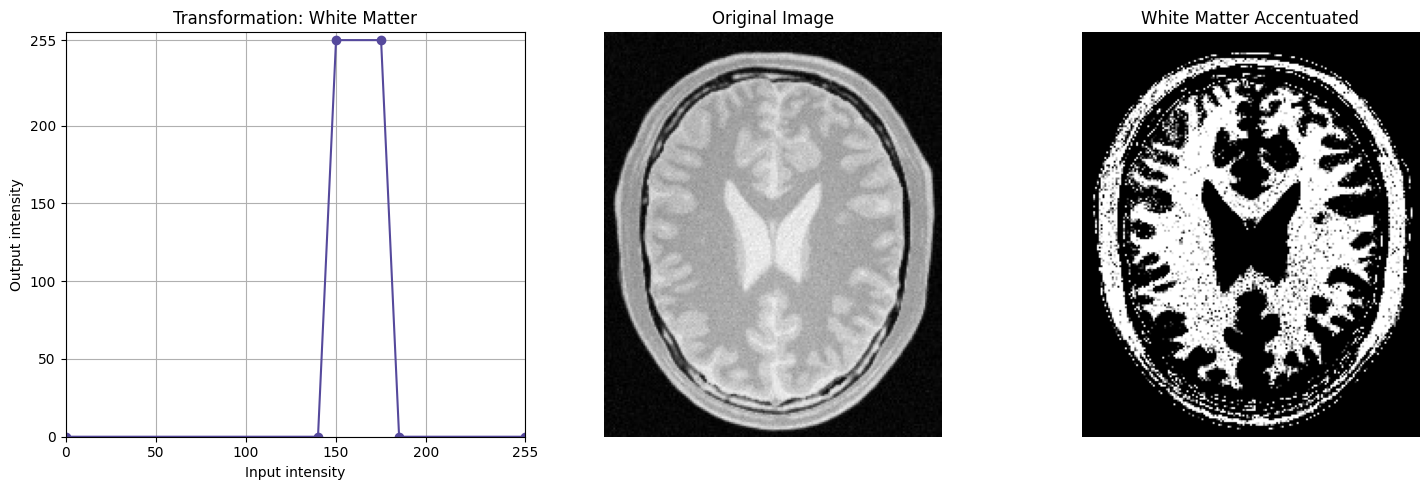

In [2]:
brain_img = cv2.imread('Images/brain.jpeg', cv2.IMREAD_GRAYSCALE)
# Breakpoints for white matter accentuation
bp_white_matter = [[0, 0], [140, 0], [150, 255], [175, 255], [185, 0], [255, 0]] 

wm_accentuated = intensity_transform(brain_img, bp_white_matter)

grid_ticks = [0, 50, 100, 150, 200, 255]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Transformation Plot
bp_wm_arr = np.array(bp_white_matter)
axes[0].plot(bp_wm_arr[:,0], bp_wm_arr[:,1], marker='o', color='#55499C')
axes[0].set_title("Transformation: White Matter"); axes[0].set_xlabel("Input intensity"); axes[0].set_ylabel("Output intensity")
axes[0].set_xlim([0, 255]); axes[0].set_ylim([0, 260])
axes[0].set_xticks(grid_ticks); axes[0].set_yticks(grid_ticks)
axes[0].grid(True)

# Original Image
axes[1].imshow(brain_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original Image"); axes[1].axis('off')

# Accentuated Image
axes[2].imshow(wm_accentuated, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("White Matter Accentuated"); axes[2].axis('off')

plt.tight_layout(); plt.show()

\vspace{-1cm}

\noindent\textbf{(b) Accentuate Gray Matter}

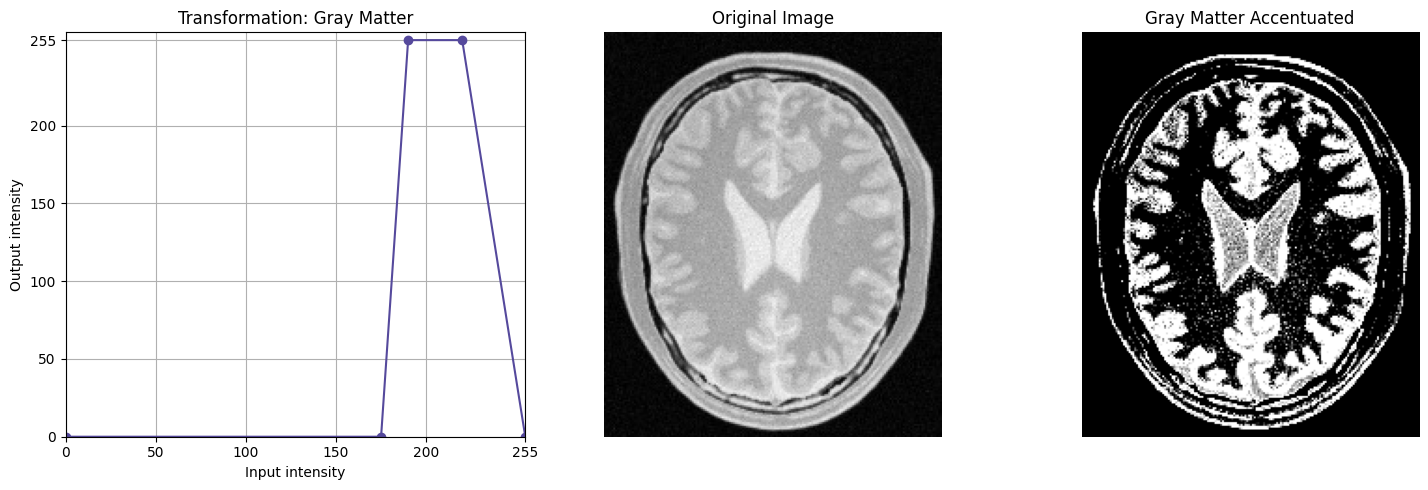

In [3]:
bp_gray_matter = [[0, 0], [175, 0], [190, 255], [220, 255], [255, 0]]
gm_accentuated = intensity_transform(brain_img, bp_gray_matter)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bp_gm_arr = np.array(bp_gray_matter)
axes[0].plot(bp_gm_arr[:,0], bp_gm_arr[:,1], marker='o', color='#55499C')
axes[0].set_title("Transformation: Gray Matter"); axes[0].set_xlabel("Input intensity"); axes[0].set_ylabel("Output intensity")
axes[0].set_xlim([0, 255]); axes[0].set_ylim([0, 260])
axes[0].set_xticks(grid_ticks); axes[0].set_yticks(grid_ticks)
axes[0].grid(True)

axes[1].imshow(brain_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original Image"); axes[1].axis('off')

axes[2].imshow(gm_accentuated, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Gray Matter Accentuated"); axes[2].axis('off')

plt.tight_layout(); plt.show()

\vspace{-1cm}

\noindent\textbf{\color{uomaccent} 3. Gamma Correction}

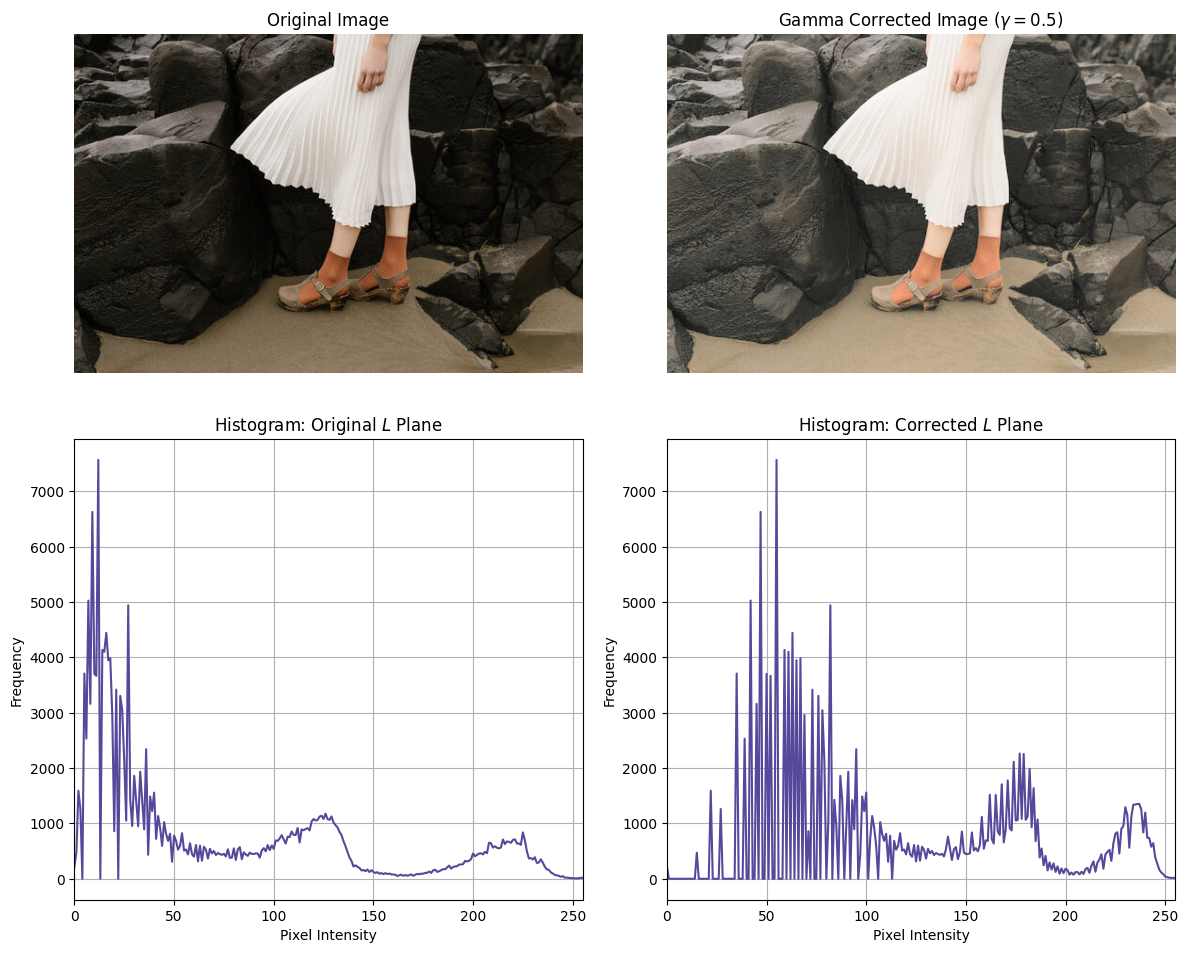

In [4]:
img_bgr = cv2.imread('Images/legs.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # For display in Matplotlib

img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB) # Convert to L*a*b* color space
L, a, b = cv2.split(img_lab)

gamma = 0.5 

# Normalize L to [0, 1], apply power law, and scale back to [0, 255]
L_normalized = L / 255.0
L_corrected = np.power(L_normalized, gamma)
L_corrected = np.uint8(L_corrected * 255)

# Merge the corrected L plane with the original a and b planes
img_lab_corrected = cv2.merge((L_corrected, a, b))
img_corrected_rgb = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2RGB)

# Compute histograms
hist_L_orig = cv2.calcHist([L], [0], None, [256], [0, 256])
hist_L_corr = cv2.calcHist([L_corrected], [0], None, [256], [0, 256])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original Image
axes[0, 0].imshow(img_rgb); axes[0, 0].set_title("Original Image"); axes[0, 0].axis('off')

# Gamma Corrected Image
axes[0, 1].imshow(img_corrected_rgb); axes[0, 1].set_title(rf"Gamma Corrected Image ($\gamma={gamma}$)")
axes[0, 1].axis('off')

# Histogram of Original L Plane
axes[1, 0].plot(hist_L_orig, color='#55499C')
axes[1, 0].set_title("Histogram: Original $L$ Plane")
axes[1, 0].set_xlabel("Pixel Intensity"); axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_xlim([0, 255]); axes[1, 0].grid(True)

# Histogram of Corrected L Plane
axes[1, 1].plot(hist_L_corr, color='#55499C')
axes[1, 1].set_title("Histogram: Corrected $L$ Plane")
axes[1, 1].set_xlabel("Pixel Intensity"); axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_xlim([0, 255]); axes[1, 1].grid(True)
plt.tight_layout(); plt.show()

\vspace{-1cm}

It is clearly observed, under $\gamma = 0.5$ the dark areas close to the bottom of the rock has been brigthened and thus enabling for the veiwers to spot more details of the image. Upon closer inspection on the two histograms, we can identify the effect of the $\gamma$ value ($0.5$).

A high concentration of low intensity pixels have been significantly shifted towards the brighter side along with a more spread (decompression). The two local maximas on the bright side of the sprectrum has also been shifted to a more brighter side, but these pixels have been compressed, which proves the behaviour of gamma correction when $\gamma < 1$.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 4. Enhancing Vibrance using Intensity Transformation}

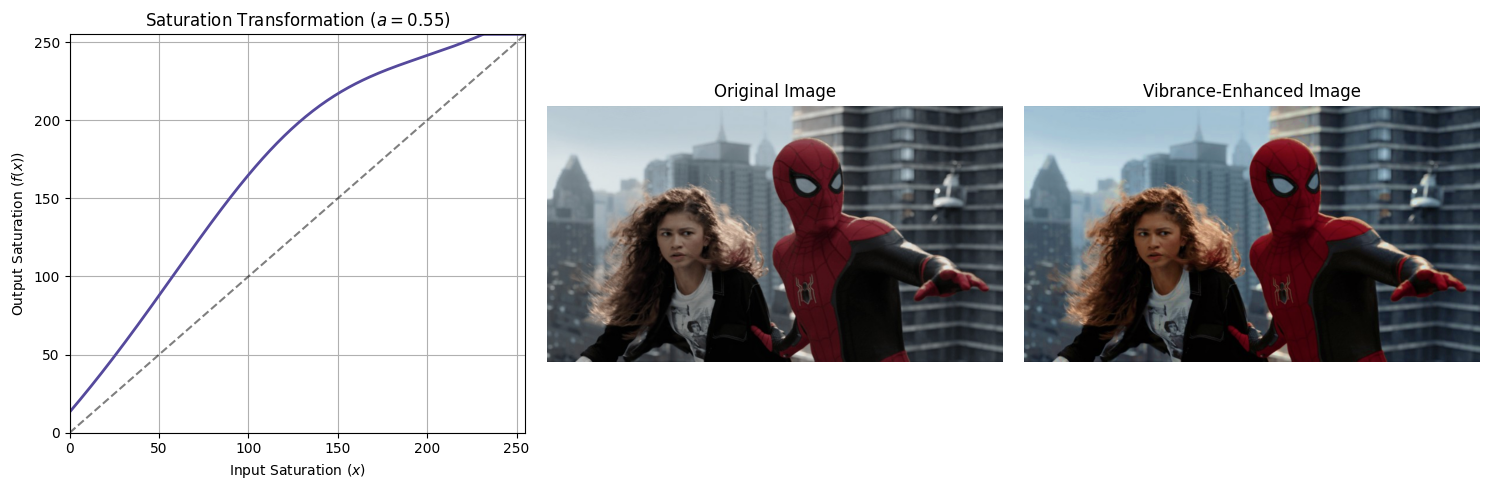

In [5]:
img_bgr = cv2.imread('Images/spider.jpeg')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to HSV color space
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(img_hsv)

a = 0.55
sigma = 70.0

# Convert S plane to float32 to prevent overflow during mathematical operations
S_float = S.astype(np.float32)

gaussian_term = np.exp(-((S_float - 128.0)**2) / (2.0 * sigma**2))
S_transformed = S_float + a * 128.0 * gaussian_term
S_transformed = np.clip(S_transformed, 0, 255).astype(np.uint8)

# Recombine the three planes
img_hsv_enhanced = cv2.merge((H, S_transformed, V))
img_enhanced_rgb = cv2.cvtColor(img_hsv_enhanced, cv2.COLOR_HSV2RGB)

# Generate the 1D intensity transformation curve 
x_vals = np.arange(0, 256, dtype=np.float32)
y_vals = x_vals + a * 128.0 * np.exp(-((x_vals - 128.0)**2) / (2.0 * sigma**2))
y_vals = np.clip(y_vals, 0, 255)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Transformation Curve
axes[0].plot(x_vals, y_vals, color='#55499C', linewidth=2)
axes[0].plot([0, 255], [0, 255], 'k--', alpha=0.5) # Reference linear line
axes[0].set_title(rf"Saturation Transformation ($a={a}$)")
axes[0].set_xlabel("Input Saturation ($x$)")
axes[0].set_ylabel("Output Saturation ($f(x)$)")
axes[0].set_xlim([0, 255]); axes[0].set_ylim([0, 255])
axes[0].grid(True)

# Original Image
axes[1].imshow(img_rgb)
axes[1].set_title("Original Image")
axes[1].axis('off')

# Enhanced Image
axes[2].imshow(img_enhanced_rgb)
axes[2].set_title("Vibrance-Enhanced Image")
axes[2].axis('off')

plt.tight_layout(); plt.show()

\vspace{-1cm}

Increasing $a$ improves the vibrancy of the image. Ranging $a$ from $0.5$ to $0.8$ did not result in significant changes. Although above 0.8 the image starts to become unrealisticly colourful. To avoid major clipping of saturation values at $255$, $a$ is chosen to be $0.55$.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 5. Histogram Equalization}

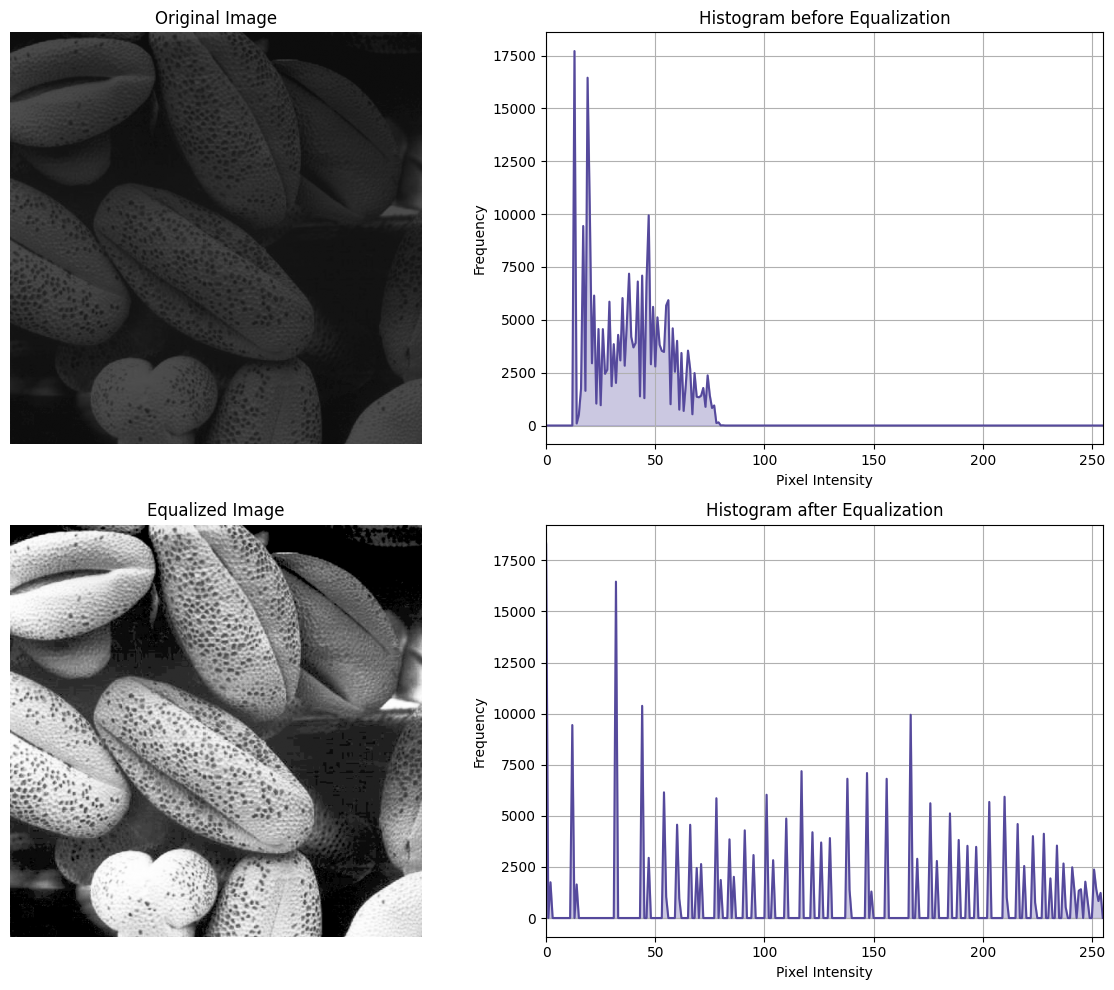

In [6]:
def histogram_equalization(img):
    # Compute the histogram
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    
    # 3. Mask out zero values in the CDF to ignore empty bins during normalization
    cdf_masked = np.ma.masked_equal(cdf, 0)
    
    # 4. Normalize the CDF to the range [0, 255]
    cdf_normalized = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    
    # 5. Fill the masked values back with 0 and cast to uint8
    cdf_final = np.ma.filled(cdf_normalized, 0).astype(np.uint8)
    
    # 6. Map the original pixel intensities to the new equalized values
    img_eq = cdf_final[img]
    
    return img_eq, hist, cdf_final

img = cv2.imread('Images/shells.tif', cv2.IMREAD_GRAYSCALE)
img_equalized, hist_orig, mapping_function = histogram_equalization(img)

# Compute the histogram 
hist_eq, _ = np.histogram(img_equalized.flatten(), 256, [0, 256])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original Image
axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

# Original Histogram
axes[0, 1].plot(hist_orig, color='#55499C')
axes[0, 1].fill_between(range(256), hist_orig, color='#55499C', alpha=0.3)
axes[0, 1].set_title("Histogram before Equalization")
axes[0, 1].set_xlabel("Pixel Intensity")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_xlim([0, 255])
axes[0, 1].grid(True)

# Equalized Image
axes[1, 0].imshow(img_equalized, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Equalized Image")
axes[1, 0].axis('off')

# Equalized Histogram
axes[1, 1].plot(hist_eq, color='#55499C')
axes[1, 1].fill_between(range(256), hist_eq, color='#55499C', alpha=0.3)
axes[1, 1].set_title("Histogram after Equalization")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True)

plt.tight_layout(); plt.show()

\vspace{-1cm}

The most clear observation is that the resulting histogram equalized image has more contrast and thus fine details are highly amplified. However this property has its drawbacks if the original image is noisy. If we assume the small black dots in the original image to be noise, and noticing that they are amplified in the output, we can conclude that the noise will also be amplified and thus result in a poorer image.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 6. Neighborhood Filtering}

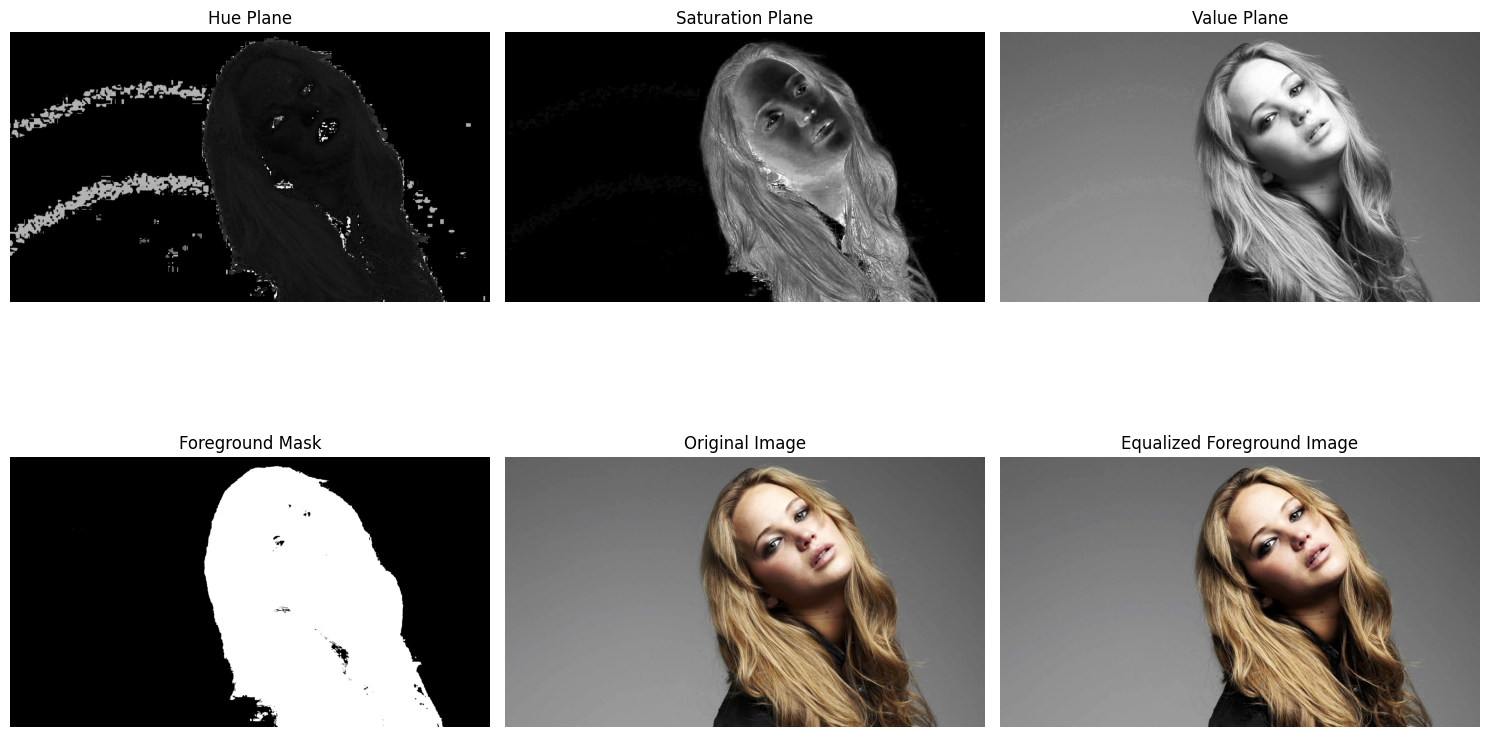

In [7]:
img_bgr = cv2.imread('Images/jennifer.jpeg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# convert to HSV color space
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(img_hsv)

# Threshold mask on saturation plane
_, mask = cv2.threshold(S, 15, 255, cv2.THRESH_BINARY)

# Obtain the foreground
fg_v = cv2.bitwise_and(V, V, mask=mask)

# Calculate the histogram of the Value plane, using the mask to ignore the background
hist_fg = cv2.calcHist([V], [0], mask, [256], [0, 256]).flatten()

# Obtain the cumulative sum of the histogram using np.cumsum
cdf = np.cumsum(hist_fg)

# Histogram-equalize the foreground
cdf_m = np.ma.masked_equal(cdf, 0) # Mask out 0s to prevent empty bins from skewing the normalization
cdf_normalized = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_normalized, 0).astype(np.uint8)

# Map the equalized values only to the foreground coordinates
V_eq = V.copy()
fg_coords = mask > 0
V_eq[fg_coords] = cdf_final[V[fg_coords]]

# Extract the background and add with the histogram equalized foreground
mask_inv = cv2.bitwise_not(mask)
bg_v = cv2.bitwise_and(V, V, mask=mask_inv)
fg_eq_v = cv2.bitwise_and(V_eq, V_eq, mask=mask)

# Add the untouched background and the equalized foreground back together
final_v = cv2.add(bg_v, fg_eq_v)

# Recombine the H, S, and new V planes, and convert back to RGB for display
final_hsv = cv2.merge((H, S, final_v))
final_rgb = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2RGB)

# Display the required planes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# The individual HSV planes in grayscale
axes[0, 0].imshow(H, cmap='gray'); axes[0, 0].set_title('Hue Plane')
axes[0, 1].imshow(S, cmap='gray'); axes[0, 1].set_title('Saturation Plane')
axes[0, 2].imshow(V, cmap='gray'); axes[0, 2].set_title('Value Plane')

# Mask, Original, and Final Result
axes[1, 0].imshow(mask, cmap='gray'); axes[1, 0].set_title('Foreground Mask')
axes[1, 1].imshow(img_rgb); axes[1, 1].set_title('Original Image')
axes[1, 2].imshow(final_rgb); axes[1, 2].set_title('Equalized Foreground Image')

for ax in axes.flatten():
    ax.axis('off')
    
plt.tight_layout(); plt.show()


\vspace{-1cm}

Hue plane is not suitable for the thresholding as we can observe it is noisy. However, the saturation plane is able to be used for the foreground mask because the background is dull and thus have lower saturation. The thresholding do miss a portion of the black dress the subject is wearing, which can be ignored.

Since the histogram equalization is applied only to the foreground, we can observe the subject is more contrast looking, with bright areas looking brighter and dark patches much darker. Which provides a sharp tone to the image.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 7. Sobel Filtering}

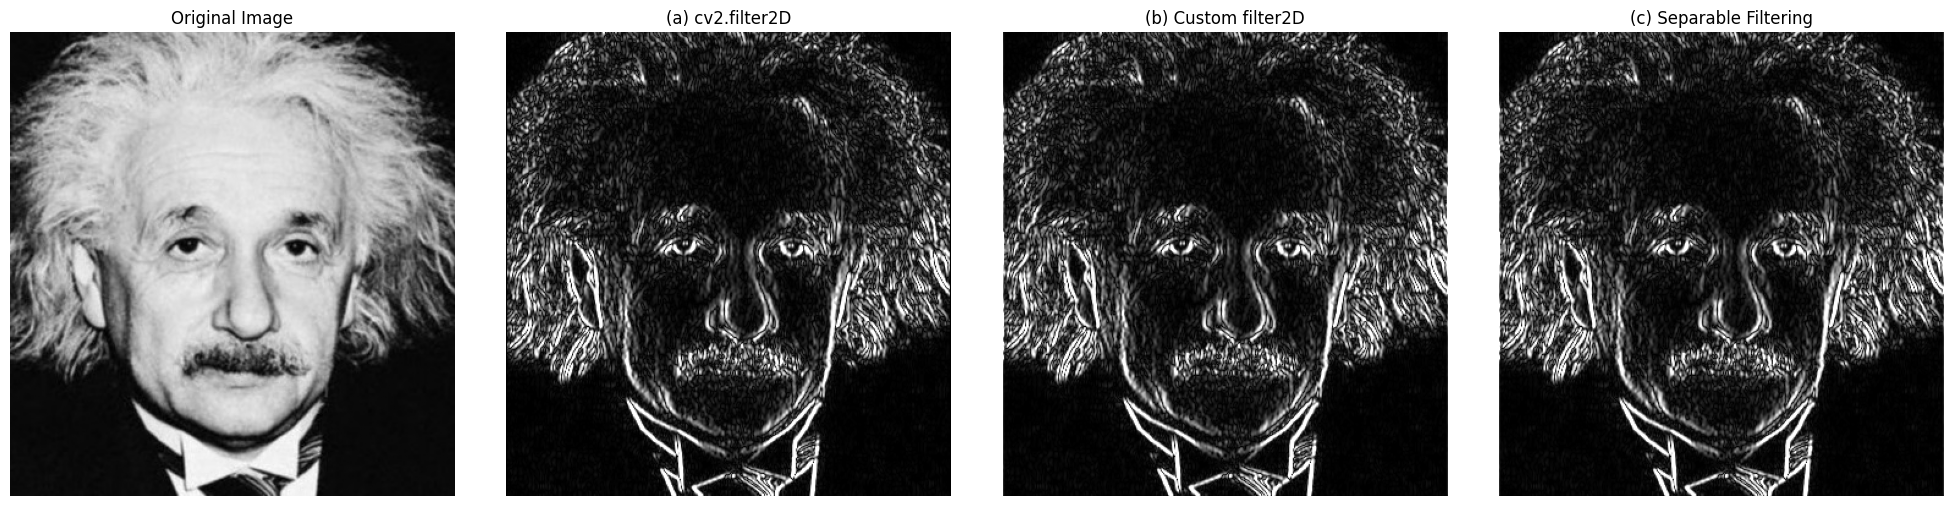

In [8]:
def custom_filter2d(image, kernel):
    """ Custom 2D spatial filter """
    i_h, i_w = image.shape
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    # Pad the image with zeros to handle edge pixels
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)
    
    # Correlation
    for i in range(k_h):
        for j in range(k_w):
            output += kernel[i, j] * padded_img[i:i+i_h, j:j+i_w]
            
    return output

img = cv2.imread('Images/einstein.jpeg', cv2.IMREAD_GRAYSCALE)
img_f = img.astype(np.float32) # Convert image to float32 to prevent overflow

# The standard 3x3 Sobel X kernel
sobel_x = np.array([[ 1,  0, -1],
                    [ 2,  0, -2],
                    [ 1,  0, -1]], dtype=np.float32)

filtered_a = cv2.filter2D(img_f, cv2.CV_32F, sobel_x) # Using cv2.filter2D
filtered_b = custom_filter2d(img_f, sobel_x) # Using the custom 2D filter

# Using the property of separability
kernel_col = np.array([[1], [2], [1]], dtype=np.float32)
kernel_row = np.array([[1, 0, -1]], dtype=np.float32)

# Filter with the column, then with the row
temp_c = custom_filter2d(img_f, kernel_col)
filtered_c = custom_filter2d(temp_c, kernel_row)

# Format floating point gradients for display
def format_for_display(gradient_img):
    abs_grad = np.abs(gradient_img)
    return np.clip(abs_grad, 0, 255).astype(np.uint8)

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original Image')
axes[1].imshow(format_for_display(filtered_a), cmap='gray'); axes[1].set_title('(a) cv2.filter2D')
axes[2].imshow(format_for_display(filtered_b), cmap='gray'); axes[2].set_title('(b) Custom filter2D')
axes[3].imshow(format_for_display(filtered_c), cmap='gray'); axes[3].set_title('(c) Separable Filtering')

for ax in axes:
    ax.axis('off')

plt.tight_layout(); plt.show()

\vspace{-1cm}

We can observe that all three methods resulted in identical outputs. Moreover upon closer observation, we realize the output is almost zero (black) for horizontal edges (changes in the $y$-direction). In the filtered outputs, horizontal features like the top of Einstein's hairline and the horizontal wrinkles on his forehead are almost absent. \newline

\textbf{Separability Property:} \newline
The spatial Sobel filter is computationally expensive as the kernel size increases. However, the $3 \times 3$ Sobel X matrix is separable, which means it can be separated into the outer product of a column vector and a row vector as follows:

$$
\begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 & -1 \end{bmatrix}
$$

By passing a $1 \times 3$ filter and then a $3 \times 1$ filter sequentially over the image, the number of multiplication operations per pixel drops from $K^2$ (9 operations) to $2K$ (6 operations), which optimizes performance by a large factor while producing the same gradient output.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 8. Image Zooming}

Results for Images/im01small.png scaled to Images/im01.png:
  - SSD (Nearest Neighbor): 0.022590
  - SSD (Bilinear):         0.017719



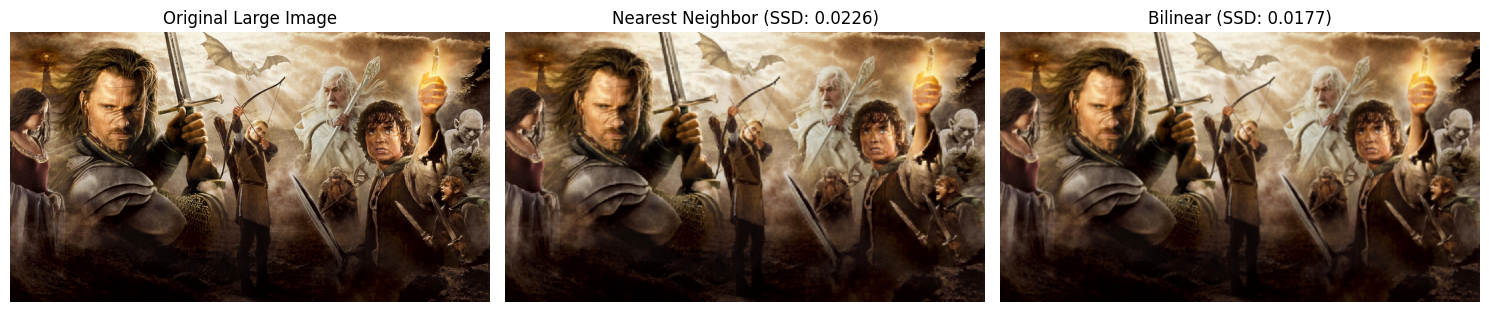

Results for Images/im02small.png scaled to Images/im02.png:
  - SSD (Nearest Neighbor): 0.010240
  - SSD (Bilinear):         0.007757



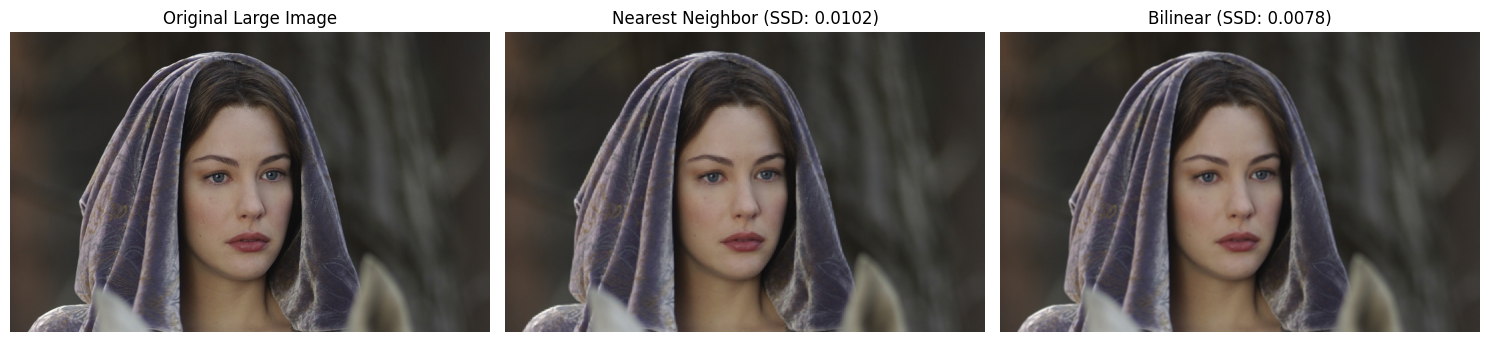

In [9]:
def zoom_image(img, factor, method='nearest'):
    """Zooms an image by a given factor s in (0, 10] using nearest-neighbor or bilinear interpolation."""        

    if not (0 < factor <= 10):
        raise ValueError("Zoom factor must be between 0 and 10.")

    h, w = img.shape[:2]
    out_h, out_w = int(h * factor), int(w * factor)
    
    # Create the output coordinate grid
    x = np.arange(out_w)
    y = np.arange(out_h)
    x_idx, y_idx = np.meshgrid(x, y)
    
    # Map back to the input coordinate space
    x_in = x_idx / factor
    y_in = y_idx / factor
    
    if method == 'nearest':
        # Round to the nearest pixel index
        x_nearest = np.clip(np.round(x_in).astype(int), 0, w - 1)
        y_nearest = np.clip(np.round(y_in).astype(int), 0, h - 1)
        return img[y_nearest, x_nearest]
        
    elif method == 'bilinear':
        # Find the 4 surrounding pixels (x0, y0), (x1, y0), (x0, y1), (x1, y1)
        x0 = np.clip(np.floor(x_in).astype(int), 0, w - 1)
        x1 = np.clip(x0 + 1, 0, w - 1)
        y0 = np.clip(np.floor(y_in).astype(int), 0, h - 1)
        y1 = np.clip(y0 + 1, 0, h - 1)
        
        # Calculate fractional distances for weights
        dx = x_in - x0
        dy = y_in - y0
        
        # Expand dimensions
        if len(img.shape) == 3:
            dx = dx[..., np.newaxis]
            dy = dy[..., np.newaxis]
            
        # Convert pixel values to float32 for math operations
        I00 = img[y0, x0].astype(np.float32)
        I01 = img[y0, x1].astype(np.float32)
        I10 = img[y1, x0].astype(np.float32)
        I11 = img[y1, x1].astype(np.float32)
        
        # Apply bilinear interpolation
        out = (I00 * (1 - dx) * (1 - dy) +
               I01 * dx * (1 - dy) +
               I10 * (1 - dx) * dy +
               I11 * dx * dy)
               
        return np.clip(out, 0, 255).astype(np.uint8)

def calc_ssd(img_original, img_zoomed):
    """Computes the Normalized Sum of Squared Differences (SSD) between two images."""
    # Ensure dimensions match exactly before calculation
    h = min(img_original.shape[0], img_zoomed.shape[0])
    w = min(img_original.shape[1], img_zoomed.shape[1])
    
    i1 = img_original[:h, :w].astype(np.float32)
    i2 = img_zoomed[:h, :w].astype(np.float32)
    
    ssd = np.sum((i1 - i2) ** 2)
    norm_factor = np.sum(i1 ** 2)
    
    return ssd / norm_factor if norm_factor != 0 else 0

# Testing the algorithm
filenames = [
    ('Images/im01small.png', 'Images/im01.png'), 
    ('Images/im02small.png', 'Images/im02.png')
]

for small_name, large_name in filenames:
    img_s = cv2.imread(small_name)
    img_l = cv2.imread(large_name)
    
    img_s_rgb = cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB)
    img_l_rgb = cv2.cvtColor(img_l, cv2.COLOR_BGR2RGB)
    
    # Scale up by a factor of 4
    zoom_nn = zoom_image(img_s_rgb, 4.0, method='nearest')
    zoom_bi = zoom_image(img_s_rgb, 4.0, method='bilinear')
    
    # Compute normalized SSD
    ssd_nn = calc_ssd(img_l_rgb, zoom_nn)
    ssd_bi = calc_ssd(img_l_rgb, zoom_bi)
    
    print(f"Results for {small_name} scaled to {large_name}:")
    print(f"  - SSD (Nearest Neighbor): {ssd_nn:.6f}")
    print(f"  - SSD (Bilinear):         {ssd_bi:.6f}\n")
    
    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_l_rgb); axes[0].set_title("Original Large Image")
    axes[1].imshow(zoom_nn); axes[1].set_title(f"Nearest Neighbor (SSD: {ssd_nn:.4f})")
    axes[2].imshow(zoom_bi); axes[2].set_title(f"Bilinear (SSD: {ssd_bi:.4f})")
    
    for ax in axes:
        ax.axis('off')
    plt.tight_layout(); plt.show()

\vspace{-1cm}

The calculated Normalized Sum of Squared Differences (SSD) shows that bilinear interpolation provides a better zooming process in terms of accuracy, for the image compared to nearest-neighbor interpolation.

When zooming by a large factor ($s = 4$), the nearest-neighbor algorithm assigns the value of the single closest source pixel. This method introduces spatial aliasing, which we can observe as jagged boundaries and blocky artifacts in the resulting image. Because of these sharp edges, pixel intensity error is increased all across the image when compared against the continuous gradients of the ground truth image, leading to a higher SSD. 

Comparatively, bilinear interpolation computes a spatial weighted average of the four surrounding source pixels based on their fractional distances. This method simply behaves as a low-pass filter by smoothing the pixel transitions. Although this can introduce slight blurring around high contrast edges, it reduces the overall pixel wise error across the image space when compared with nearest-neighbour, resulting in a lower SSD and thus a smoother reconstruction.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 9. Image Segmentation and Enhancement}

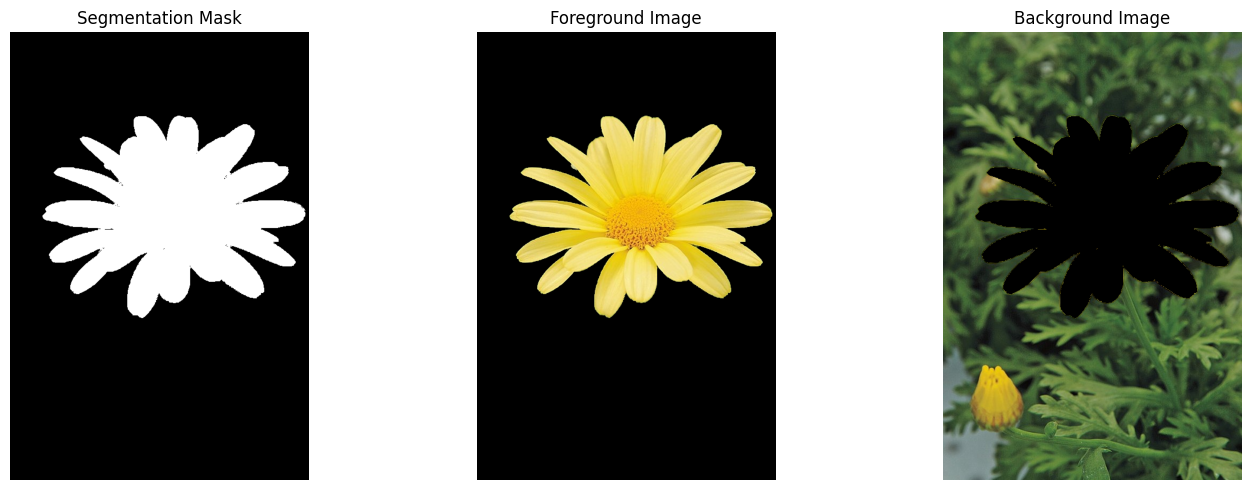

In [10]:
img_bgr = cv2.imread('Images/flower.jpeg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Variables for grabCut
mask = np.zeros(img_bgr.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Bounding box around the flower only not the bud.
h, w = img_bgr.shape[:2]
rect = (int(w * 0.1), int(h * 0.1), int(w * 0.9), int(h * 0.65))

# Apply grabCut (5 iterations)
cv2.grabCut(img_bgr, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Creating binary mask where foreground is 1 and background is 0.
binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# Extract foreground and background using the binary mask
fg_image = img_rgb * binary_mask[:, :, np.newaxis]
mask_inv = 1 - binary_mask
bg_image = img_rgb * mask_inv[:, :, np.newaxis]

# Segmentation Mask, Foreground, Background
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
axes1[0].imshow(binary_mask, cmap='gray')
axes1[0].set_title("Segmentation Mask")
axes1[1].imshow(fg_image)
axes1[1].set_title("Foreground Image")
axes1[2].imshow(bg_image)
axes1[2].set_title("Background Image")
for ax in axes1: ax.axis('off')
plt.tight_layout(); plt.show()

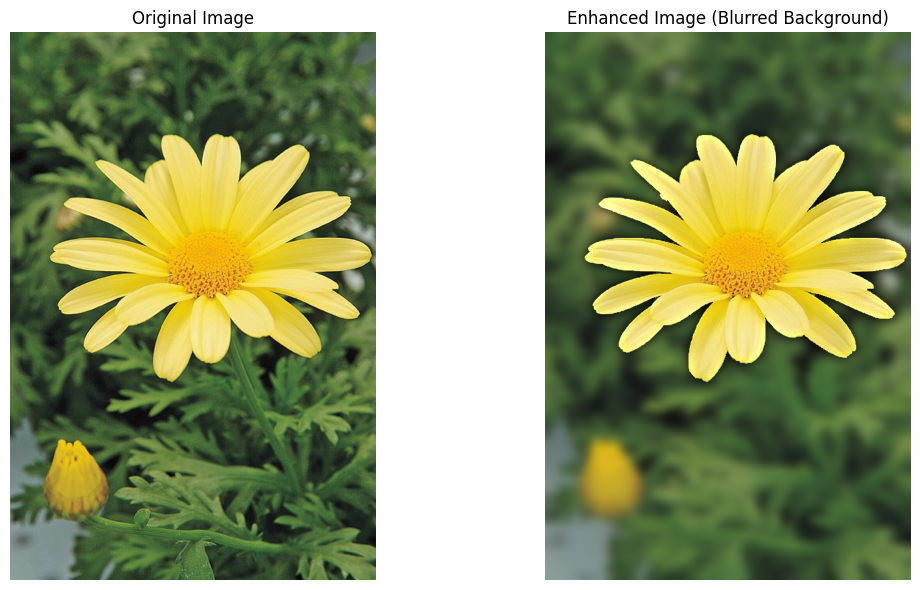

In [11]:
# Produce enhanced image with a blurred background
blurred_bg = cv2.GaussianBlur(bg_image, (51, 51), 0) # Strong Gaussian blur on the isolated background
enhanced_image = cv2.add(fg_image, blurred_bg) # Recombination without overflowing

# Original vs Enhanced
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6))
axes2[0].imshow(img_rgb)
axes2[0].set_title("Original Image")
axes2[1].imshow(enhanced_image)
axes2[1].set_title("Enhanced Image (Blurred Background)")
for ax in axes2: ax.axis('off')
plt.tight_layout(); plt.show()

\vspace{-1cm}

\textbf{Observation on the Dark Halo:} \newline
A somewhat darker border appearing around the flower in the enhanced image is an artifact of applying a Gaussian blur to the isolated background. When the background is separated, the region where the foreground flower used to be, become pure black. As the large Gaussian kernel slides over the edges of the isolated background, it averages the true background pixels with the black pixels from the empty foreground. This process makes the surrounding edge intensities go down, which results in a dark halo along the edge of the flower.

\vspace{0.5cm}

\noindent\textbf{\color{uomaccent} 10. Bilateral Filtering}

\vspace{0.2cm}
\noindent\textbf{(a) OpenCV Implementation}

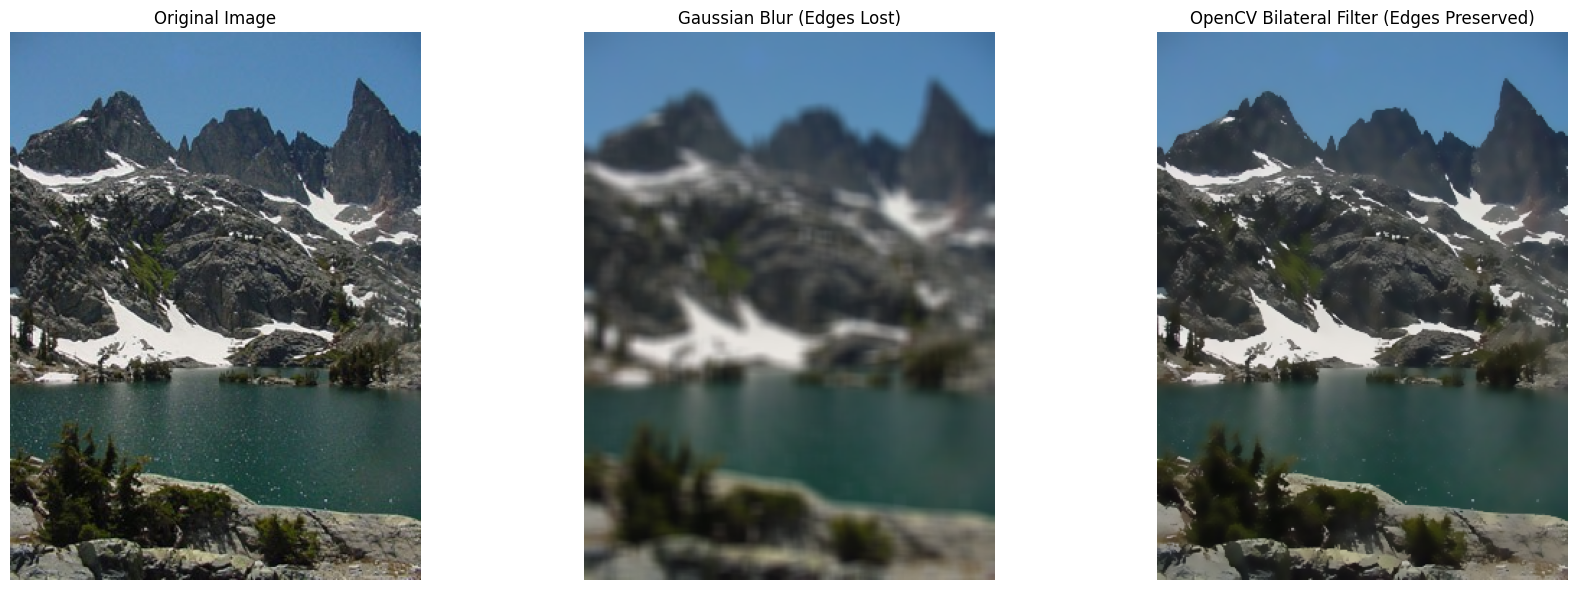

In [12]:
img_bgr = cv2.imread('Images/mountains.jpeg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Parameters
d = 9          # Diameter of the pixel neighborhood
sigma_r = 75.0 # Filter sigma in the color space (larger = more flat regions smoothed)
sigma_s = 75.0 # Filter sigma in the coordinate space (larger = wider blur radius)

# OpenCV implementations
cv2_bilateral = cv2.bilateralFilter(img_rgb, d, sigma_r, sigma_s)
cv2_gaussian = cv2.GaussianBlur(img_rgb, (d, d), sigma_s)

# Display the original, Gaussian blurred, and bilateral filtered images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb); axes[0].set_title('Original Image')
axes[1].imshow(cv2_gaussian); axes[1].set_title('Gaussian Blur (Edges Lost)')
axes[2].imshow(cv2_bilateral); axes[2].set_title('OpenCV Bilateral Filter (Edges Preserved)')

for ax in axes:
    ax.axis('off')
    
plt.tight_layout(); plt.show()

\vspace{0.2cm}
\noindent\textbf{(b) Custom Bilateral Filter Implementation}

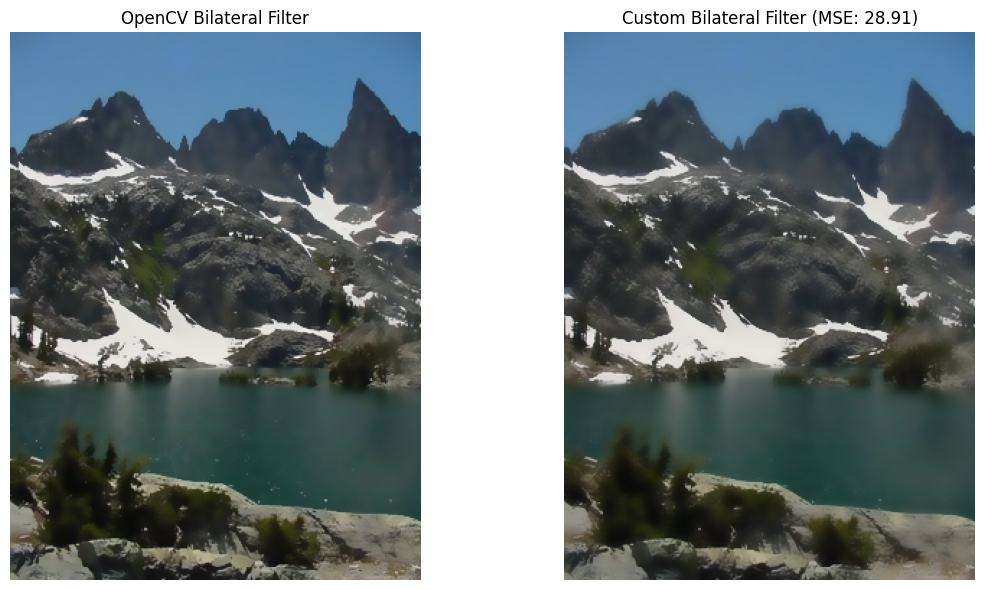

Mean Squared Error (OpenCV vs Custom Bilateral): 28.9092


In [13]:

def custom_bilateral_filter(img, diameter, sigma_r, sigma_s):
    """Applies a custom bilateral filter to an RGB image."""
    img_f = img.astype(np.float32)
    result = np.zeros_like(img_f)
    radius = diameter // 2
    
    # Precompute the spatial Gaussian weights
    y, x = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_gaussian = np.exp(-(x**2 + y**2) / (2.0 * sigma_s**2))
    
    # Pad the image to handle borders
    padded_img = cv2.copyMakeBorder(img_f, radius, radius, radius, radius, cv2.BORDER_REFLECT)
    
    # Iterate over every pixel
    h, w, c = img.shape
    for i in range(h):
        for j in range(w):
            # Extract the local window for the current pixel
            window = padded_img[i:i+diameter, j:j+diameter, :]
            center_pixel = padded_img[i+radius, j+radius, :]
            
            # Compute the range Gaussian weights dynamically (based on color intensity differences)
            color_diff_sq = np.sum((window - center_pixel)**2, axis=2)
            range_gaussian = np.exp(-color_diff_sq / (2.0 * sigma_r**2))
            
            # Multiply spatial and range weights to get the final bilateral weights
            bilateral_weights = spatial_gaussian * range_gaussian
            
            # Normalize the weights so they sum to 1
            weight_sum = np.sum(bilateral_weights)
            
            # Apply weights to the window and sum to get the new pixel values for each channel
            for k in range(c):
                result[i, j, k] = np.sum(bilateral_weights * window[:, :, k]) / weight_sum
                
    return np.clip(result, 0, 255).astype(np.uint8)

def calc_mse(imageA, imageB):
    """Computes the Mean Squared Error between two images for quantitative comparison."""
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1] * imageA.shape[2])
    return err

custom_bilat = custom_bilateral_filter(img_rgb, d, sigma_r, sigma_s)

# MSE as Quantitative measure 
mse_score = calc_mse(cv2_bilateral, custom_bilat)


# Display OpenCV vs Custom for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2_bilateral); axes[0].set_title('OpenCV Bilateral Filter')
axes[1].imshow(custom_bilat); axes[1].set_title(f'Custom Bilateral Filter (MSE: {mse_score:.2f})')

for ax in axes:
    ax.axis('off')
        
plt.tight_layout(); plt.show()

print(f"Mean Squared Error (OpenCV vs Custom Bilateral): {mse_score:.4f}")

\textbf{Quantitative Comparison Discussion:} \newline
The Mean Squared Error (MSE) was used as the quantitative measure to compare the custom implementation with OpenCV's built-in `bilateralFilter`. An MSE near 0 confirms that the custom function is identical to the OpenCV backend. While Gaussian blur averages spatial distances without discrimination, which erases the sharp transitions of the mountain edges against the sky, both bilateral filtering outputs maintain these edges while successfully smoothing out texture noise in the water and rock faces.